In [93]:
#for exp2: My suggestion is to create three functions and then test the whole thing in a simple for loop.
#  1. Write a Function to Create the Parameterized Entangled State: Create a 2-qubit circuit that starts 
# in |00>, applies a Hadamard on qubit 0, then a CNOT, then applies RY(theta) on qubit 0. 


from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit_aer import  AerSimulator as Aer
from qiskit.quantum_info import Statevector, Operator, Pauli
from qiskit.circuit.library import RZGate
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as tck

# First function
def create_entangled_state(theta):
    qc = QuantumCircuit(2)
    qc.h(0)  # Apply Hadamard on qubit 0
    qc.cx(0, 1)  # Apply CNOT with control=0 and target=1
    qc.ry(theta, 0)  # Apply RY on qubit 0
    return qc



In [94]:
# 2.  Write a Function to Measure Correlation ZxZ; apply local measurement settings on each qubit. 
# This function should: Take a Statevector of your 2-qubit system then 
# Apply a rotation around the Z-axis on each qubit (to choose measurement basis) and lastly
# Calculate the expectation value of Z|xZ 

def measure_correlation(state, angle_0, angle_1, term):
    """
    Measure the ZxZ correlation for the given statevector and angles.

    Args:
        state (Statevector): The 2-qubit statevector.
        angle_0 (float): Rotation angle for qubit 0.
        angle_1 (float): Rotation angle for qubit 1.
        term (str): The Pauli term to measure ('ZZ', 'ZX', 'XZ', or 'XX').

    Returns:
        float: The expectation value of ZxZ.
    """
    # Define Z as an Operator
    #Z = Operator([[1, 0], [0, -1]])  # Pauli-Z operator

    # Define rotation operators as Operators
    #Rz_0 = Operator([[np.exp(-1j * angle_0 / 2), 0], [0, np.exp(1j * angle_0 / 2)]])
    #Rz_1 = Operator([[np.exp(-1j * angle_1 / 2), 0], [0, np.exp(1j * angle_1 / 2)]])

    #combined_rotation = Rz_0.tensor(Rz_1)  
    # Apply rotations to the state
    #rotated_state = state.evolve(combined_rotation)
    
    # Define ZxZ as an Operator
    #ZxZ = Z.tensor(Z)

    # Calculate the expectation value
    #expectation_value = np.real(rotated_state.expectation_value(ZxZ))
     # Define the terms to compute

    # Why do we put Operator and not just Pauli("")? The Pauli class represents a single Pauli operator 
    # (like Z, Y etc.), but to use it in operations such as tensor products or expectation value calculations,
    # you would need to convert it to an Operator.
     
    Z=Operator(Pauli("Z"))
    X=Operator(Pauli("X"))
    
    chsh_value = 0

    if term == "ZZ":
        operator = Z.tensor(Z)
    elif term == "ZX":
        operator = Z.tensor(X)
    elif term == "XZ":
        operator = X.tensor(Z)
    elif term == "XX":
        operator = X.tensor(X)
    else:
        raise ValueError("Invalid term. Must be 'ZZ', 'ZX', 'XZ', or 'XX'.")
        
    rz_0 = RZGate(angle_0).to_matrix()
    rz_1 = RZGate(angle_1).to_matrix()
    combined_rotation = Operator(rz_0).tensor(Operator(rz_1))
    # Calculate expectation value for the term
    rotated_state = state.evolve(combined_rotation)
    # Compute the expectation value
    expectation_value = rotated_state.expectation_value(operator)

    return np.real(expectation_value)



# 3. final function, calculate s via inputing state and angles you want to test. 

def chsh_s_value(state, angles):
    """
    Compute the CHSH S-value for a given state and angles. 
    Args:
        state (Statevector): The 2-qubit statevector.
        angles (dict): A dictionary with angles {'A': float, 'a': float, 'B': float, 'b': float}.

    Returns:
        float: The absolute CHSH S-value.
    """
    A, a, B, b = angles['A'], angles['a'], angles['B'], angles['b']
    
    # Compute the expectation values
    E_A_B = measure_correlation(state, A, B, "ZZ")
    E_A_b = measure_correlation(state, A, b, "ZX")
    E_a_B = measure_correlation(state, a, B, "XZ")
    E_a_b = measure_correlation(state, a, b, "XX")
    #E_A_B = measure_correlation(state, A, B)
    #E_A_b = measure_correlation(state, A, b)
    #E_a_B = measure_correlation(state, a, B)
    #E_a_b = measure_correlation(state, a, b)

    # Calculate the S-value
    S_1 = E_A_B - E_A_b + E_a_B + E_a_b
    S_2 = E_A_B + E_A_b - E_a_B + E_a_b
    return S_1, S_2, E_A_B, E_A_b, E_a_B, E_a_b



In [95]:
from qiskit.quantum_info import Statevector

# Main script cobining all 3 functions 
def main():
   
    # Range of thetas to test
    thetas = np.linspace(0, 2 * np.pi, 21)
    s_1values = [] 
    s_2values = [] 
    e_AB=[]
    e_Ab=[]
    e_aB=[]
    e_ab=[]
    states=[]
    
    # Angles for CHSH inequality
    angles = {
        'A': 0,
        'a': np.pi/2,
        'B': np.pi/4,
        'b': -np.pi/4
    }

    for theta in thetas:
        # Build circuit
        qc = create_entangled_state(theta)

        state = Statevector(qc) 
        states.append(state)
        
        # Compute CHSH S-value
        S_value1, S_value2, expected_AB, expected_Ab, expected_aB, expected_ab= chsh_s_value(state, angles)

        e_AB.append(expected_AB)
        e_Ab.append(expected_Ab)
        e_aB.append(expected_aB)
        e_ab.append(expected_ab)
        s_1values.append(S_value1)
        s_2values.append(S_value2)
    
    print(states) 
    # Print results
    for theta, S_value1 in zip(thetas, s_1values):
        print(f"Theta: {theta:.2f}, CHSH inequality, S_1-value: {S_value1:.2f}")

    for theta, expected_AB in zip(thetas, e_AB):
        print(f"Theta: {theta:.2f}, CHSH inequality, AB-value: {expected_AB:.2f}")
    for theta, expected_Ab in zip(thetas, e_Ab):
        print(f"Theta: {theta:.2f}, CHSH inequality, Ab-value: {expected_Ab:.2f}")
    for theta, expected_aB in zip(thetas, e_aB):
        print(f"Theta: {theta:.2f}, CHSH inequality, aB-value: {expected_aB:.2f}")

    for theta, S_value2 in zip(thetas, s_2values):
        print(f"Theta: {theta:.2f}, CHSH inequality, S_2-value: {S_value2:.2f}")

    # Graph S vs. angle variation

    fig, ax = plt.subplots(figsize=(10, 6))

    # results from hardware
    ax.plot(thetas / np.pi, s_1values, "o-", label="S_1", zorder=3)
    ax.plot(thetas / np.pi, s_2values, "o-", label="S_2", zorder=3)
    # results from hardware
    #ax.plot(thetas/ np.pi, e_AB, "o-", label="<AB>", zorder=3)
    #ax.plot(thetas / np.pi, e_Ab, "o-", label="<Ab>", zorder=3)
    #ax.plot(thetas / np.pi, e_aB, "o-", label="<aB>", zorder=3)
    #ax.plot(thetas / np.pi, e_ab, "o-", label="<ab>", zorder=3)

    # classical bound +-2
    ax.axhline(y=2, color="0.9", linestyle="--")
    ax.axhline(y=-2, color="0.9", linestyle="--")

    # quantum bound, +-2√2
    ax.axhline(y=np.sqrt(2) * 2, color="0.9", linestyle="-.")
    ax.axhline(y=-np.sqrt(2) * 2, color="0.9", linestyle="-.")
    ax.fill_between(thetas / np.pi, 2, 2 * np.sqrt(2), color="0.6", alpha=0.7)
    ax.fill_between(thetas / np.pi, -2, -2 * np.sqrt(2), color="0.6", alpha=0.7)

    # Details 
    ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
    ax.xaxis.set_major_locator(tck.MultipleLocator(base=0.5))


    plt.xlabel("Angle for Degree of Entanglement")
    plt.ylabel("S value")
    plt.legend()
    plt.show()

[Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2)), Statevector([ 0.69840112+0.j,  0.11061587+0.j, -0.11061587+0.j,
              0.69840112+0.j],
            dims=(2, 2)), Statevector([ 0.67249851+0.j,  0.21850801+0.j, -0.21850801+0.j,
              0.67249851+0.j],
            dims=(2, 2)), Statevector([ 0.63003676+0.j,  0.32101976+0.j, -0.32101976+0.j,
              0.63003676+0.j],
            dims=(2, 2)), Statevector([ 0.5720614 +0.j,  0.41562694+0.j, -0.41562694+0.j,
              0.5720614 +0.j],
            dims=(2, 2)), Statevector([ 0.5+0.j,  0.5+0.j, -0.5+0.j,  0.5+0.j],
            dims=(2, 2)), Statevector([ 0.41562694+0.j,  0.5720614 +0.j, -0.5720614 +0.j,
              0.41562694+0.j],
            dims=(2, 2)), Statevector([ 0.32101976+0.j,  0.63003676+0.j, -0.63003676+0.j,
              0.32101976+0.j],
            dims=(2, 2)), Statevector([ 0.21850801+0.j,  0.67249851+0.j, -0.67249851+0.j,
            

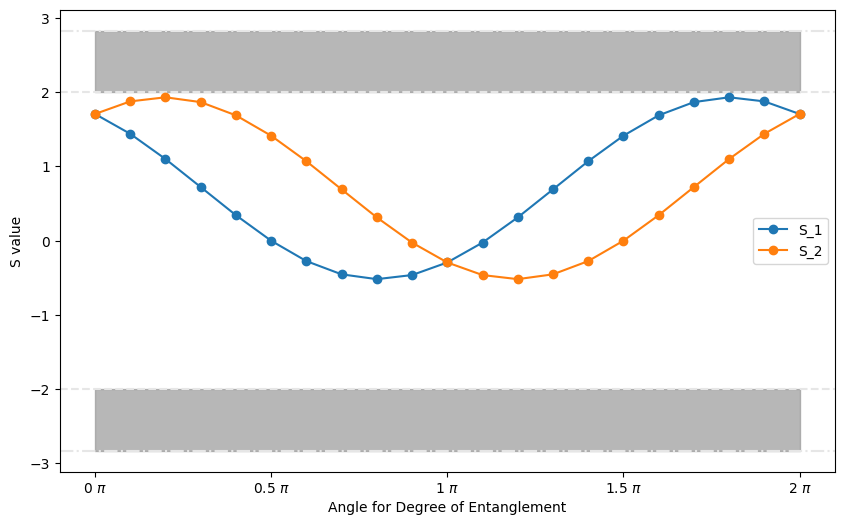

In [96]:
main()